<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/4_modulo/4_modulo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/4_modulo/4_modulo.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

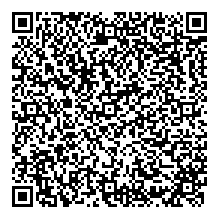

In [1]:
# QR para el cuaderno de clase que permite lectura activa y experimental
import qrcode
from PIL import Image
import os

# URL del notebook en GitHub
url = "https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/4_modulo/4_modulo.ipynb"

# Configuración del QR
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=3,
    border=4,
)

# Añadir datos al QR
qr.add_data(url)
qr.make(fit=True)

# Crear imagen del QR
img = qr.make_image(fill_color="black", back_color="white")

# Guardar imagen
output_path = "github_notebook_qr.png"
img.save(output_path)

# Mostrar imagen generada (solo si se ejecuta en Jupyter Notebook/Lab)
try:
    display(Image.open(output_path))
except:
    print(f"Código QR generado y guardado en: {os.path.abspath(output_path)}")
    print("Ábralo con cualquier visor de imágenes o escanéelo con su móvil.")
    img.show()  # Abre la imagen en el visor predeterminado



### [Video de apoyo a la lectura del módulo 4 del texto de Clara Mejía Laverde](https://www.youtube.com/watch?v=P-A2BjQmEgA)

[Video de presentación en tableta digital de algún ejemplo del módulo 4: Cómo resolver un sistema con Gauss Jordan](https://www.youtube.com/watch?v=KWFJFEQhTww)

[Video de apoyo a la presentación del ejemplo 2 de este módulo 4 con tableta](https://www.youtube.com/watch?v=Hi_c--dtMg0)

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno](https://www.youtube.com/watch?v=SKzvZyACoNg)

[Presentación del módulo 4: Independencia lineal pero con el enfoque de ciencia de datos con Python](https://www.youtube.com/watch?v=iy_Eji5JzOU)

### [Vínculo al programa del curso: Linear_Algebra ](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/0_programa_cronograma_curso/1_programa_linear_algebra/1_programa_linear_algebra.md)



#### Código del curso: 5009329

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/linear_algebra/blob/main/images/geo_vectorial_ultima_clase_2025-11-04.jpg?raw=true' width = 300> 



In [5]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/linear_algebra.xlsx'
df = pd.read_excel(path)
df.index = range(1, len(df) + 1)
df.head(11) 


,Cédula,Nombre,Email
1,1007676529,ARENAS HERAZO GABRIEL ENRIQUE,gabriel.arenas@udea.edu.co
2,1038547924,ARROYAVE ECHAVARRIA LAURA SOFIA,sofia.arroyave@udea.edu.co
3,1007528664,AYALA MENDOZA MARISOL YACIRA,marisol.ayala@udea.edu.co
4,1007676170,CANTILLO ENSUCHO DANIEL,daniel.cantillo@udea.edu.co
5,1038104030,IBAÑEZ MORENO FRANCISCO LUIS,francisco.ibanez@udea.edu.co
6,1066570075,MONTERROSA SOTO ABRIL,a.monterrosa@udea.edu.co
7,1038099623,NORIEGA JIMENEZ GABRIELA,gabriela.noriega@udea.edu.co
8,1129805618,PEREZ THERAN ERLINDA,erlinda.perez@udea.edu.co
9,1038101968,QUINONEZ CERVANTES MARIANA,mariana.quinonezc@udea.edu.co
10,1007318378,RAMOS PEREZ YANINE,y.ramos@udea.edu.co


# Módulo 4 Independencia lineal.    




* [Álgebra Lineal de Clara Elena Mejía Laverde](https://www.academia.edu/43065939/Alg_Lineal_Clara_Mejia_Universidad_de_Ant) 

In [2]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------------
# VECTORES
# -------------------------

v1 = np.array([2,1,1])
v2 = np.array([4,2,2])   # paralelo a v1

u1 = np.array([2,1,0])
u2 = np.array([0,2,1])   # no paralelo

# -------------------------
# FIGURA CON DOS ESCENAS
# -------------------------

fig = make_subplots(
rows=1, cols=2,
specs=[[{'type':'scene'}, {'type':'scene'}]],
subplot_titles=("Vectores paralelos → Recta",
                "Vectores no paralelos → Plano")
)

# -------------------------
# FUNCION EJES
# -------------------------

def axes(scene_col):

    L=4
    
    fig.add_trace(go.Scatter3d(
        x=[0,L],y=[0,0],z=[0,0],
        mode='lines',
        line=dict(color='red',width=6),
        showlegend=False),
        row=1,col=scene_col)

    fig.add_trace(go.Scatter3d(
        x=[0,0],y=[0,L],z=[0,0],
        mode='lines',
        line=dict(color='green',width=6),
        showlegend=False),
        row=1,col=scene_col)

    fig.add_trace(go.Scatter3d(
        x=[0,0],y=[0,0],z=[0,L],
        mode='lines',
        line=dict(color='blue',width=6),
        showlegend=False),
        row=1,col=scene_col)

# -------------------------
# EJES
# -------------------------

axes(1)
axes(2)

# -------------------------
# CASO 1: RECTA
# -------------------------

t=np.linspace(-2,2,50)

line=np.outer(t,v1)

fig.add_trace(go.Scatter3d(
x=line[:,0],
y=line[:,1],
z=line[:,2],
mode='lines',
line=dict(width=8,color='black'),
name='Recta generada'
),row=1,col=1)

# vectores

for v in [v1,v2]:

    fig.add_trace(go.Scatter3d(
    x=[0,v[0]],
    y=[0,v[1]],
    z=[0,v[2]],
    mode='lines+markers',
    marker=dict(size=3),
    line=dict(width=10),
    showlegend=False
    ),row=1,col=1)

    fig.add_trace(go.Cone(
    x=[v[0]],
    y=[v[1]],
    z=[v[2]],
    u=[v[0]],
    v=[v[1]],
    w=[v[2]],
    sizemode="absolute",
    sizeref=0.4,
    showscale=False
    ),row=1,col=1)

# -------------------------
# CASO 2: PLANO
# -------------------------

s=np.linspace(-1.5,1.5,10)
t=np.linspace(-1.5,1.5,10)

S,T=np.meshgrid(s,t)

plane = np.zeros((10,10,3))

for i in range(10):
    for j in range(10):
        plane[i,j] = S[i,j]*u1 + T[i,j]*u2

fig.add_trace(go.Surface(
x=plane[:,:,0],
y=plane[:,:,1],
z=plane[:,:,2],
opacity=0.6,
showscale=False
),row=1,col=2)

# vectores del plano

for v in [u1,u2]:

    fig.add_trace(go.Scatter3d(
    x=[0,v[0]],
    y=[0,v[1]],
    z=[0,v[2]],
    mode='lines+markers',
    marker=dict(size=3),
    line=dict(width=10),
    showlegend=False
    ),row=1,col=2)

    fig.add_trace(go.Cone(
    x=[v[0]],
    y=[v[1]],
    z=[v[2]],
    u=[v[0]],
    v=[v[1]],
    w=[v[2]],
    sizemode="absolute",
    sizeref=0.4,
    showscale=False
    ),row=1,col=2)

# -------------------------
# LAYOUT
# -------------------------

fig.update_layout(
height=600,
width=1100,
title="Subespacios generados por vectores en $R^3$"
)

fig.show()

fig.write_image(r"C:\Users\marco\Downloads\parallel_non_parallel_vectors.png")

## Contenidos del módulo  



1. Definición y ejemplos de conjuntos linealmente independientes (LI) y linealmente dependientes (LD)


2. Interpretación geométrica de la dependencia lineal en $\mathbb{R}^{3}$. 

 
3. Propiedades

## Objetivos del módulo  



1. Establecer los conceptos de dependencia e independencia lineal.


2. Interpretar geométricamente el significado de la dependencia lineal en $\mathbb{R}^{3}$.


3. Vincular la teoría de espacios vectoriales con los sistemas de ecuaciones lineales y los determinantes.

# Preguntas básicas


1. ¿Cuándo un conjunto es LD?


2. ¿Cuándo un conjunto es LI?


3. ¿Qué significa que un subconjunto de tres vectores de $\mathbb{R}^{3}$ es LD.  


4. ¿Tiene sentido hablar de un vector LI?  
    
   Un vector $v$ es LI si la única manera de obtener el cero por combinación lineal de él, es con la forma trivial $cv = 0$, con $c = 0$. Si $c$ puede ser diferente de cero, entonces el vector es LD. Mientras que si $c$ tiene que ser cero, entonces el vector es LI. 


5. ¿Por qué los conceptos de independencia y dependencia lineal se vinculan con la solución de sistemas homogéneos de ecuaciones lineales?

# Introducción  



En el módulo anterior vimos que pueden tenerse infinitud de conjuntos generadores de un espacio vectorial.   



Es claro, por razones de economía, que lo que se desea es hallar los conjuntos generadores más pequeños posibles para los espacios vectoriales.   



Para lograr esto se requiere el concepto de independencia lineal.  



Mostraremos el significado de independencia lineal y su relación con la teoría de sistemas homogéneos de ecuaciones y determinantes.

# Definición y ejemplos de conjuntos linealmente independientes (LI) y linealmente dependientes (LD)  



# Definición 1  

Sean $\mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}$, $n$ vectores diferentes de un espacio vectorial $V$. 

Se dice que los vectores son *linealmente dependientes*, LD, si existen $n$ escalares $c_{1}, c_{2}, \ldots, c_{n}$ **no todos cero**, tales que: 

$$
c_{1}\mathbf{v}_{1} + c_{2}\mathbf{v}_{2} + \cdots + c_{n}\mathbf{v}_{n} = \mathbf{0}
$$

Si los vectores no son linealmente dependientes, se dice que son linealmente independientes, LI, es decir, la ecuación:   
 

$$
c_{1}\mathbf{v}_{1} + c_{2}\mathbf{v}_{2} + \cdots + c_{n}\mathbf{v}_{n} = \mathbf{0}
$$

es válida sólo si $c_{1} = c_{2} = \cdots = c_{n} = 0$.   



Si los vectores $\mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}$ son distintos y formamos el conjunto $A = \{\mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}\}$
entonces también decimos que el conjunto $A$ es LD o LI según el caso.  



Es claro que la ecuación $c_{1}\mathbf{v}_{1} + c_{2}\mathbf{v}_{2} + \cdots + c_{n}\mathbf{v}_{n} = \mathbf{0}$ siempre se satisface si elegimos todos los escalares $c_{1}, c_{2}, \ldots, c_{n}$  iguales a cero.  

Lo  importante es ver si es posible satisfacer la ecuación con al menos uno de los escalares diferente de cero.

# Ejemplos  



# 1. En $\mathbb{R}^{3}$, sea $A = \{(1, 7, -2), (-1, 1, 0), (3,5.-2)\}$ veamos si $A$ es LI o LD.   

### [Video de apoyo a el estudio de este ejemplo](https://www.youtube.com/watch?v=KWFJFEQhTww)

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------
# VECTORES
# -----------------------

v1 = np.array([1,7,-2])
v2 = np.array([-1,1,0])
v3 = np.array([3,5,-2])

# -----------------------
# FIGURA
# -----------------------

fig = make_subplots(
rows=1, cols=2,
specs=[[{'type':'scene'}, {'type':'scene'}]],
subplot_titles=("Vectores en $R^3$",
                "Plano generado por los vectores")
)

# -----------------------
# EJES COORDENADOS
# -----------------------

def draw_axes(col):

    L = 8

    fig.add_trace(go.Scatter3d(
        x=[0,L], y=[0,0], z=[0,0],
        mode='lines',
        line=dict(color='red', width=6),
        showlegend=False
    ), row=1, col=col)

    fig.add_trace(go.Scatter3d(
        x=[0,0], y=[0,L], z=[0,0],
        mode='lines',
        line=dict(color='green', width=6),
        showlegend=False
    ), row=1, col=col)

    fig.add_trace(go.Scatter3d(
        x=[0,0], y=[0,0], z=[0,L],
        mode='lines',
        line=dict(color='blue', width=6),
        showlegend=False
    ), row=1, col=col)

draw_axes(1)
draw_axes(2)

# -----------------------
# FUNCION PARA VECTORES
# -----------------------

def draw_vector(v, col):

    fig.add_trace(go.Scatter3d(
        x=[0,v[0]],
        y=[0,v[1]],
        z=[0,v[2]],
        mode='lines+markers',
        marker=dict(size=3),
        line=dict(width=10),
        showlegend=False
    ), row=1, col=col)

    fig.add_trace(go.Cone(
        x=[v[0]],
        y=[v[1]],
        z=[v[2]],
        u=[v[0]],
        v=[v[1]],
        w=[v[2]],
        sizemode="absolute",
        sizeref=0.6,
        showscale=False
    ), row=1, col=col)

# -----------------------
# GRAFICO 1: VECTORES
# -----------------------

for v in [v1, v2, v3]:
    draw_vector(v,1)

# -----------------------
# PLANO
# -----------------------

s = np.linspace(-1.5,1.5,15)
t = np.linspace(-1.5,1.5,15)

S,T = np.meshgrid(s,t)

plane = np.zeros((15,15,3))

for i in range(15):
    for j in range(15):
        plane[i,j] = S[i,j]*v1 + T[i,j]*v2

fig.add_trace(go.Surface(
    x=plane[:,:,0],
    y=plane[:,:,1],
    z=plane[:,:,2],
    opacity=0.6,
    showscale=False
), row=1, col=2)

# vectores sobre el plano

for v in [v1, v2, v3]:
    draw_vector(v,2)

# -----------------------
# LAYOUT
# -----------------------

fig.update_layout(
title="Vectores y plano generado en $R^3$",
height=650,
width=1100
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\vectors_and_plane.png")

## Solución:  



Comenzamos planteando la ecuación 

$$ 
c_{1}(1, 7, -2) + c_{2}(-1, 1, 0) + c_{3}(3, 5, -2) = (0,0,0)
$$  



la cual, igualando los componentes en ambos lados de la ecuación, nos lleva al siguiente sistema homogéneo de ecuaciones:  

$$
\begin{align}
c_{1} -c_{2} + 3c_{3} & = 0 \\  
7c_{1} + c_{2} + 5c_{3} & = 0  \\  
-2c_{1} - 2c_{3} & = 0   
\end{align}
$$


# 1. Resolución simbólica directa con **SymPy**

Este enfoque imita el procedimiento algebraico clásico.


In [2]:
import sympy as sp

# Variables
c1, c2, c3 = sp.symbols('c1 c2 c3')

# Sistema
ecuaciones = [
    c1 - c2 + 3*c3,
    7*c1 + c2 + 5*c3,
    -2*c1 - 2*c3
]

# Resolver
solucion = sp.solve(ecuaciones, [c1, c2, c3])
solucion


{c1: -c3, c2: 2*c3}

La solución obtenida del sistema es: 

$$
S = \{(c_{1}, c_{2}, c_{3}) \mid c_{1} = -c_{3}, \ c_{2} = 2c_{3}, \ c_{3} \in \mathbb{R}\}
$$  



$$
S = \left\{  \begin{pmatrix}c_{1}\\ c_{2} \\ c_{3} \end{pmatrix} \mid c_{3} \begin{pmatrix}-1\\ 2\\ 1 \end{pmatrix}, c_{3} \in \mathbb{R} \right\}
$$

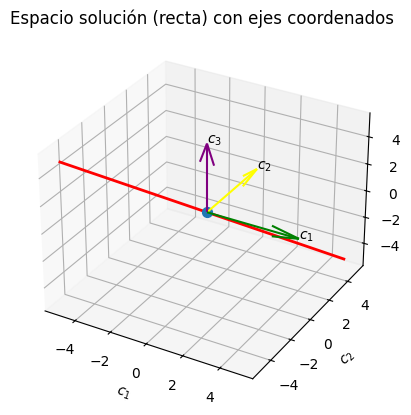

<Figure size 640x480 with 0 Axes>

In [3]:
# Graficamos la solución del sistema 

import numpy as np
import matplotlib.pyplot as plt

# Vector director del espacio solución
v = np.array([-1, -1, 1])

# Parámetro
t = np.linspace(-5, 5, 100)

# Recta solución
x = t * v[0]
y = t * v[1]
z = t * v[2]

# Figura 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Recta solución
ax.plot(x, y, z, linewidth=2, color = 'red')
ax.scatter(0, 0, 0, s=50)  # origen

# Ejes coordenados
axis_len = 5
ax.quiver(0, 0, 0, axis_len, 0, 0, color = 'green')
ax.quiver(0, 0, 0, 0, axis_len, 0, color = 'yellow')
ax.quiver(0, 0, 0, 0, 0, axis_len, color = 'purple')

ax.text(axis_len, 0, 0, r'$c_1$')
ax.text(0, axis_len, 0, r'$c_2$')
ax.text(0, 0, axis_len, r'$c_3$')

ax.set_xlabel(r'$c_1$')
ax.set_ylabel(r'$c_2$')
ax.set_zlabel(r'$c_3$')

ax.set_title('Espacio solución (recta) con ejes coordenados')

plt.show()

ax.set_xlabel(r'$c_1$')
ax.set_ylabel(r'$c_2$')
ax.set_zlabel(r'$c_3$')

ax.set_title('Espacio solución del sistema homogéneo')
plt.savefig(r"C:\Users\marco\Downloads\espacio_solucion_sistema_homogeneo.png")
plt.show()


In [4]:
import plotly.graph_objects as go
import numpy as np

# Vector director
v = np.array([-1, -1, 1])

# Parámetro
t = np.linspace(-5, 5, 100)

# Recta solución
x = t * v[0]
y = t * v[1]
z = t * v[2]

fig = go.Figure()

# Recta solución
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines',
    name='Espacio solución'
))

# Origen
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    name='Origen'
))

# Ejes coordenados
axis_len = 5
fig.add_trace(go.Scatter3d(
    x=[0, axis_len], y=[0, 0], z=[0, 0],
    mode='lines',
    name='Eje c1'
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, axis_len], z=[0, 0],
    mode='lines',
    name='Eje c2'
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[0, axis_len],
    mode='lines',
    name='Eje c3'
))

fig.update_layout(
    title='Espacio solución del sistema homogéneo',
    scene=dict(
        xaxis_title='c1',
        yaxis_title='c2',
        zaxis_title='c3'
    )
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\espacio_solucion.png")


Un ejemplo de solución es $c_{3} = 0$, entonces $c_{1} = 0$ y $c_{2} = 0$. Y otra solición es si $c_{3} = 1$, entonces $c_{1} = -1$ y $c_{2} = 2$. 

Por lo tanto, $A$ es un conjunto LD. 


- **Interpretación**
SymPy te da la solución paramétrica automáticamente (si existe un espacio de soluciones no trivial).

---



# 2. Forma matricial y **espacio nulo (nullspace)**



Este es el enfoque **conceptualmente más importante en álgebra lineal**.

## Sistema en forma matricial

$$
A\mathbf{c} = 0
$$



In [5]:
A = sp.Matrix([
    [1, -1,  3],
    [7,  1,  5],
    [-2, 0, -2]
])

# Espacio nulo
null = A.nullspace()
null


[Matrix([
 [-1],
 [ 2],
 [ 1]])]


- **Resultado**

* `nullspace()` devuelve una **base del espacio de soluciones**
* Cada vector representa una solución independiente. 



- La solución general es una combinación lineal de esos vectores.

---



# 3. Reducción por filas (Gauss–Jordan)



Ideal para mostrar el método clásico, pero automatizado.


In [6]:
A_aumentada = A.row_join(sp.zeros(3, 1))  # matriz aumentada
A_aumentada

Matrix([
[ 1, -1,  3, 0],
[ 7,  1,  5, 0],
[-2,  0, -2, 0]])

In [ ]:
A_rref, pivots = A_aumentada.rref()

A_rref, pivots # que es lo que el componente pivots representa
# El componente pivots representa las columnas que contienen los pivotes en la matriz reducida por filas (rref). 
# En este caso, los pivotes están en las columnas 0 y 1, lo que indica que las variables correspondientes a esas 
# columnas son las variables básicas, mientras que la variable correspondiente a la columna 2 es una variable libre.


(Matrix([
 [1, 0,  1, 0],
 [0, 1, -2, 0],
 [0, 0,  0, 0]]),
 (0, 1))

- Aquí puedes:

* Identificar variables libres
* Construir la solución paso a paso como en el tablero

---



# 4. Resolución numérica con **NumPy** (SVD)

En sistemas homogéneos, NumPy no usa `solve`, sino **descomposición en valores singulares**.


In [7]:
import numpy as np

A_np = np.array([
    [1, -1,  3],
    [7,  1,  5],
    [-2, 0, -2]
], dtype=float)

# SVD
U, S, Vt = np.linalg.svd(A_np)

# Vector asociado al valor singular más pequeño
null_vec = Vt[-1]
null_vec


array([ 0.40824829, -0.81649658, -0.40824829])


- **Clave conceptual**

* El último vector de `Vt` genera el **espacio nulo**
* Es una solución **aproximada**, pero muy útil en ciencia de datos y ML

---



# 5. Verificación automática de la solución

Siempre bonito cerrar con verificación:


In [6]:
null[0]

Matrix([
[-1],
[ 2],
[ 1]])

In [13]:
A @ null[0]


Matrix([
[0],
[0],
[0]])

o en NumPy:


In [14]:
A_np @ null_vec


array([ 4.44089210e-16,  3.10862447e-15, -8.88178420e-16])


Debe dar el **vector cero** (o muy cercano).

---



# 6. Interpretación matemática final

* Es un **sistema homogéneo**
* Tiene soluciones no triviales ⇔ `det(A) = 0`
* El conjunto solución es un **subespacio vectorial** de ℝ³
* En este caso, es una **recta que pasa por el origen**

---


# 2. En $\mathbb{P}_{2}$, sea $B = \{-1 + x^{2}, 2+x, x^{2}\}$. ¿Es $B$ LI o LD?.  


[Video de apoyo a la presentación de este ejemplo con tableta](https://www.youtube.com/watch?v=Hi_c--dtMg0)


## Solución:  

Dada la ecuación

$$
c_{1}(-1+x^{2}) + c_{2}(2+x) + c_{3}(x^{2}) = 0 + 0x + 0x^{2}.  
$$

Veamos cómo son $c_{1}, c_{2}$ y $c_{3}$.  

Empecemos aplicando propiedad distributiva de la multiplicación con respecto a la suma: 

$$
-c_{1} + c_{1}x^{2} + 2c_{2} + c_{2}x + c_{3}x^{2} = 0 + 0x + 0x^{2}
$$  



Sumemos términos semejantes: 

$$
(-c_{1} + 2c_{2}) + (c_{2})x + (c_{1}+ c_{3})x^{2} = 0 + 0x + 0x^{2}
$$



Apliquemos el principio de igualdad de polinomios: 

$$
\begin{align}
-c_{1} + 2c_{2} & = 0 \\  
c_{2}           & = 0 \\  
c_{1} + c_{3}   & = 0 
\end{align}
$$

de donde $c_{1} = c_{2} = c_{3} = 0$. De donde, $B$ es LI. 

In [8]:
# dame una representación con plotliy de las funciones del conjunto B # 2. En $\mathbb{P}_{2}$, sea $B = \{-1 + x^{2}, 2+x, x^{2}\}$. ¿Es $B$ LI o LD?.  
# y a la derecha de este gráfico los vectores de R3 asociados a cada función del conjunto B y el plano que contiene a dos de estos vectores.

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dominio
x = np.linspace(-4,4,200)

f1 = -1 + x**2
f2 = 2 + x
f3 = x**2

# Vectores asociados
v1 = np.array([-1,0,1])
v2 = np.array([2,1,0])
v3 = np.array([0,0,1])

# Figura con dos paneles
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type":"xy"},{"type":"scene"}]],
    subplot_titles=("Funciones del conjunto B", "Vectores asociados en R3")
)

# --- FUNCIONES ---
fig.add_trace(go.Scatter(x=x,y=f1,mode='lines',name='-1 + x²'),row=1,col=1)
fig.add_trace(go.Scatter(x=x,y=f2,mode='lines',name='2 + x'),row=1,col=1)
fig.add_trace(go.Scatter(x=x,y=f3,mode='lines',name='x²'),row=1,col=1)

# --- VECTORES ---
def vector_trace(v,name):
    return go.Scatter3d(
        x=[0,v[0]],
        y=[0,v[1]],
        z=[0,v[2]],
        mode='lines+markers',
        line=dict(width=6),
        name=name
    )

fig.add_trace(vector_trace(v1,"-1 + x²"),row=1,col=2)
fig.add_trace(vector_trace(v2,"2 + x"),row=1,col=2)
fig.add_trace(vector_trace(v3,"x²"),row=1,col=2)

# --- PLANO generado por v1 y v2 ---
s = np.linspace(-1.5,1.5,10)
t = np.linspace(-1.5,1.5,10)

S,T = np.meshgrid(s,t)

X = v1[0]*S + v2[0]*T
Y = v1[1]*S + v2[1]*T
Z = v1[2]*S + v2[2]*T

fig.add_trace(
    go.Surface(x=X,y=Y,z=Z,opacity=0.5,showscale=False,name="Plano(v1,v2)"),
    row=1,col=2
)

fig.update_layout(
    height=600,
    width=1100,
    title="Funciones y representación vectorial"
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\funciones_vectores.png")

# Proposiciones  



1. Dos vectores en un espacio vectorial $V$ son LD si y sólo si uno de ellos es un múltiplo escalar del otro.


Tarea. 
justifica esta afirmación  
($\Leftarrow$)
$$v_{2} = \alpha v_{1}, \alpha \neq 0 $$

$$ -\alpha v_{1} + v_{2} = 0 $$

$\{ v_{1}, v_{2}\}$ es LD. 


2. Todo conjunto que tenga como elemento el módulo de un espacio vectorial es LD.


## Tarea. 
justifica esta afirmación  


3. Todo conjunto unitario cuyo elemento no sea el módulo es LI.  

Tarea. 
justifica esta afirmación  


# 4.2 Interpretación geométrica de la dependencia lineal en $\mathbb{R}^{3}$.  



Suponga que $u, v$ y $w$, son tres vectores LD en $\mathbb{R}^{3}$; entonces existen escalares $c_{1}, c_{2}, c_{3}$, no todos cero, tales que:

$$
c_{1}\mathbf{u} + c_{2}\mathbf{v} + c_{3}\mathbf{w} = \mathbf{0}
$$

Suponga que $c_{3} \neq 0$, entonces 

$$
c_{3}w = -c_{1} u - c_{2} v
$$



de donde 

$$
w = \frac{-c_{1}}{c_{3}} u + \frac{-c_{2}}{c_{3}} v = \alpha u + \beta v
$$

con $\alpha = \frac{-c_{1}}{c_{3}}$ y $\beta = \frac{-c_{2}}{c_{3}}$.  



Veamos entonces que  $u, v$ y $w$ son coplanares:  

$$
\begin{align}
w \cdot (u \times v) & =  (\alpha u + \beta v) \cdot (u \times v) \\  
                     & = (\alpha u) \cdot (u \times v) + (\beta v) \cdot (u \times v)  \\  
                     & = \alpha (u \cdot (u \times v)) + \beta (v \cdot (u \times v))  \\  
                     & = \alpha(0) + \beta (0) = 0 
\end{align}
$$

Recuerde que tres vectores del espacio son coplanares si y sólo si su producto triple es igual a cero.  

¿Por qué $u \cdot (u \times v)$ y $v \cdot (u \times v)$ son iguales a cero?

En conclusión: si $u, v, w$, son tres vectores LD en $\mathbb{R}^{3}$, ellos son coplanares.

¿Será cierta la recíproca de esta implicación? Es decir, si $\mathbf{u}, \mathbf{v}, \mathbf{w}$ son tres vectores coplanares de $\mathbb{R}^{3}$ entonces $\mathbf{u}, \mathbf{v}, \mathbf{w}$ son LD. 

## Tarea

Responda a esta pregunta de manera fundamentada. 

# 4.3 Propiedades  



# Teorema 1  

Un conjunto de $n$ vectores de $\mathbb{R}^{m}$ siempre es LD si $n > m$.  



# Corolario  

Un conjunto de vectores LI en $\mathbb{R}^{n}$ contiene a lo más $n$ vectores.

# Teorema 2  

Sea 

$$
A = \begin{bmatrix} 
a_{11} & a_{12} & \cdots& a_{1n} \\  
a_{21} & a_{22} & \cdots & a_{2n} \\  
\vdots & \vdots & \vdots & \vdots \\  
a_{m1} & a_{m2} & \cdots & a_{mn} \\
 \end{bmatrix}
$$  

Entonces las columnas de $A$ consideradas como vectores son LD si y sólo si el sistema $A\mathbf{x}=0$ tiene soluciones no triviales (diferentes de $\mathbf{x} = \mathbf{0}$).

# Teorema 3  

Sean $v_{1}, v_{2}, \ldots, v_{n}$, $n$ vectores en $\mathbb{R}^{n}$ y sea $A$ una matriz $n \times n$ cuyas columnas son $v_{1}, v_{2}, \ldots, v_{n}$. Entonces $v_{1}, v_{2}, \ldots, v_{n}$ son LI si y sólo si la única solución al sistema homogéneo $Ax=0$ es la trivial.

# Teorema 4   

Sea $A$ una matriz $n \times n$. Entonces $det(A) \neq 0$ si y sólo si las columnas de $A$ son LI. 

# Teorema 5  

Todo conjunto de $n$ vectores LI en $\mathbb{R}^{n}$ genera a $\mathbb{R}^{n}$.

# Teorema 6  

Sea $S = \{ \mathbf{v}_{1}, \mathbf{v}_{2}, \ldots, \mathbf{v}_{n}\} \subset V$.     
$S$ es LD si y sólo si existe al menos un vector de $S$ que pueda expresarse como combinación lineal de los vectores restantes de $S$.

# Observación  

Si un conjunto $S$ LD genera un espacio vectorial $V$, el conjunto que resulta de eliminar en $S$ un vector que sea combinación lineal del resto de vectores de $S$ también genera el espacio vectorial $V$.

# Ejemplo 3  



Sea el conjunto de vectores $S = \{v_{1}, v_{2}, v_{3}, v_{4}\} \subset \mathbb{R}^{4}$ con 

$$
v_{1} = \begin{bmatrix} 1\\ 1 \\ 0 \\ 0 \end{bmatrix}, \quad v_{2} = \begin{bmatrix} 1\\ 0 \\ 1 \\ 0 \end{bmatrix}, \quad v_{3} = \begin{bmatrix} 0\\ 1 \\ 1 \\0  \end{bmatrix}, \quad v_{4} = \begin{bmatrix}2 \\ 1 \\ 1 \\ 0 \end{bmatrix}, \quad
$$



Sea $W = gen(S)$. Como $v_{4} = v_{1} + v_{2}$, entonces $W = gen(S_{1})$, donde $S_{1} = \{v_{1}, v_{2}, v_{3}\}$

# Ejercicios del módulo 4  

En los ejercicios 1 a 4 muestre por inspección que los vectores son linealmente dependientes, LD.  

1. $u_{1} = (2,3)$, $u_{2} = (-4, -6)$, $\mathbb{R}^{2}$
2. $u_{1}$ 

# 10. Determine si el conjunto de vectores dado es LI o LD

$$
\left\{ 
\begin{bmatrix}
-1&3&2 \\ 
0&0&0\end{bmatrix}, 
 \begin{bmatrix}
0&6&4 \\ 
4&6&2 \end{bmatrix}, 
\begin{bmatrix}
1&0&0 \\ 
2&3&1 \end{bmatrix}, 
 \right\}
$$

Queremos determinar si el conjunto de matrices

$$
\left{
\begin{bmatrix}
-1&3&2 \
0&0&0
\end{bmatrix},
\begin{bmatrix}
0&6&4 \
4&6&2
\end{bmatrix},
\begin{bmatrix}
1&0&0 \
2&3&1
\end{bmatrix}
\right}
$$

es **linealmente independiente (LI)** o **linealmente dependiente (LD)**.

---

# 1. Idea matemática

Las matrices pertenecen al espacio vectorial $M_{2\times3}(\mathbb{R})$.

Para verificar independencia lineal debemos resolver

$$
c_1A_1+c_2A_2+c_3A_3=0
$$

donde

$$
A_1=
\begin{bmatrix}
-1&3&2\
0&0&0
\end{bmatrix},
\quad
A_2=
\begin{bmatrix}
0&6&4\
4&6&2
\end{bmatrix},
\quad
A_3=
\begin{bmatrix}
1&0&0\
2&3&1
\end{bmatrix}
$$

Si la **única solución** es

$$
c_1=c_2=c_3=0
$$

entonces el conjunto es **LI**.

---

# 2. Vectorización de matrices

Cada matriz se puede convertir en un vector de $\mathbb{R}^6$:

$$
A_1 \rightarrow (-1,3,2,0,0,0)
$$

$$
A_2 \rightarrow (0,6,4,4,6,2)
$$

$$
A_3 \rightarrow (1,0,0,2,3,1)
$$

Formamos la matriz con estos vectores como columnas:

$$
M=
\begin{bmatrix}
-1 & 0 & 1\
3 & 6 & 0\
2 & 4 & 0\
0 & 4 & 2\
0 & 6 & 3\
0 & 2 & 1
\end{bmatrix}
$$

La independencia lineal se verifica calculando el **rango**.

---

# 3. Resolución con **SymPy**

```python


In [ ]:
import sympy as sp

# Definir matrices
A1 = sp.Matrix([
[-1,3,2],
[0,0,0]
])

A2 = sp.Matrix([
[0,6,4],
[4,6,2]
])

A3 = sp.Matrix([
[1,0,0],
[2,3,1]
])

# Vectorizar matrices
v1 = sp.Matrix(A1).reshape(6,1)
v2 = sp.Matrix(A2).reshape(6,1)
v3 = sp.Matrix(A3).reshape(6,1)

# Construir matriz de vectores
M = sp.Matrix.hstack(v1, v2, v3)

# Rango
rango = M.rank()

M, rango


```

---

# 4. Forma escalonada reducida

Podemos además calcular:

```python


In [ ]:
M.rref()


Resultado:

$$
\begin{bmatrix}
1&0&0\\ 
0&1&0\\ 
0&0&1\\ 
0&0&0\\ 
0&0&0\\ 
0&0&0
\end{bmatrix}
$$

---



# 5. Interpretación

El **rango es**

$$
\text{rango}(M)=3
$$

y coincide con el número de vectores.

Por lo tanto,

$$
c_1=c_2=c_3=0
$$

es la única solución.

---



# 6. Conclusión

El conjunto

$$
\left{
\begin{bmatrix}
-1&3&2\
0&0&0
\end{bmatrix},
\begin{bmatrix}
0&6&4\
4&6&2
\end{bmatrix},
\begin{bmatrix}
1&0&0\
2&3&1
\end{bmatrix}
\right}
$$

es

$$
\boxed{\text{Linealmente Independiente (LI)}}
$$

---



✅ **Interpretación geométrica:**
Estas tres matrices forman un conjunto de **tres vectores independientes en el espacio vectorial $M_{2\times3}(\mathbb{R})$**, que tiene dimensión

$$
2\times3=6
$$

por lo que generan un **subespacio de dimensión 3**.

---



Si quieres, también puedo mostrarte **cómo resolverlo construyendo directamente la combinación lineal con SymPy (método más didáctico para estudiantes)**, que suele ser la forma más clara de enseñarlo en **Álgebra Lineal con Python**.


### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/5_modulo/5_modulo.ipynb)

# Cursos que orienta el profesor Marco Julio Cañas Campillo en 2025  

1. Lunes 8 a 11: Asesoría Trabajo de Grado Janis (Estudiante de Biología).   
2. Lunes 3 a 5 PM:  
3. Lunes 5 PM a 8 PM: Pivu Caucasia.  
4. Martes de 9 a 11:  
5. Martes 11 AM a 12 M: Asesoría en Álgebra Lineal Matemáticos. 
6. Martes de 2 a 6 PM: Álgebra Lineal. 
7. Miércoles 8 - 11 M:   
8. Miércoles: 2 a 3:  
9. Jueves 8 a 12: Fundamentos de Programación.  
10. Jueves 2 a 6 PM:   
11. Viernes 8 a 12: Asesoría en matemáticas para estudiantes del campus. 
12. Viernes 2 a 6 PM:    
13. Sábado 6 AM - 6 PM: PIVU Puerto Libertador.   

## Referentes 


* [Álgebra Lineal de Clara Elena Mejía Laverde](https://www.academia.edu/43065939/Alg_Lineal_Clara_Mejia_Universidad_de_Ant)  


* R. Duval y Semiosis y pensamiento humano, 2.ª ed. Cali, Colombia: Programa Editorial Universidad del Valle, 2017. [En línea]. Disponible en: https://programaeditorial.univalle.edu.co/gpd-semiosis-y-pensamiento-humano-9789587655278-63324cdb0f6b3.html


* Wing, J. M. (2006). Computational thinking. Communications of the ACM, 49(3), 33-35. https://doi.org/10.1145/1118178.1118215
  


* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)



* [chatGPT](https://openai.com/blog/chatgpt)  



* [Géron, A. (2017). Hands-on machine learning with scikit-learn and tensorflow: Concepts. Tools, and Techniques to build intelligent systems.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)   



* [McKinney, W. (2012). Python for data analysis: Data wrangling with Pandas, NumPy, and IPython. " O'Reilly Media, Inc.".](https://wesmckinney.com/book/) 

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado. Este hijo me enorgullece y me hace falta abrazarlo cada día. 

Y a mi esposa Yasmira Emperatriz Barboza Mogollón por su apoyo, orientación y acompañamiento. 


# Módulo 4

# Independencia Lineal

## Detectando información redundante en los datos

---



# 1. Motivación desde ciencia de datos y agro

En un sistema agrícola se registran variables:

* lluvia
* humedad del suelo
* agua en el suelo medida por sensores



Pero ocurre algo:

La variable **agua en el suelo** puede estimarse casi completamente por

$$
\text{agua_en_el_suelo} = 0.8 \cdot lluvia + 0.6 \cdot humedad
$$



Entonces una de las variables **no aporta información nueva**.

Esto es exactamente lo que estudia la **independencia lineal**.

En ciencia de datos esto aparece como:

* multicolinealidad
* redundancia
* variables dependientes.

---



# 2. Exploración con Python

Creamos tres variables donde una depende de las otras.



In [ ]:
import numpy as np # Genera vectores aleatorios y 
import pandas as pd # 

np.random.seed(1)

lluvia = np.random.normal(loc = 0, scale = 1, size=200)
humedad = np.random.normal(size=200)

agua_suelo = 0.8*lluvia + 0.6*humedad

df = pd.DataFrame({
"lluvia": lluvia,
"humedad": humedad,
"agua_suelo": agua_suelo
})

df.head()


,lluvia,humedad,agua_suelo
0,1.624345,-0.400878,1.058949
1,-0.611756,0.824006,0.004998
2,-0.528172,-0.562305,-0.759921
3,-1.072969,1.954878,0.314552
4,0.865408,-1.331952,-0.106845


Discusión con estudiantes:

¿Son realmente tres variables independientes?

---



# 3. Observación geométrica

Cada fila del dataset es un vector

$$
x = (lluvia, humedad, agua)
$$



Pero todos los datos satisfacen

$$
agua - 0.8\cdot lluvia - 0.6\cdot humedad = 0
$$

Los datos viven en un **plano dentro de $\mathbb{R}^{3}$**.

---



# 4. Experimento visual


In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, x="lluvia", y="humedad", z="agua_suelo")
fig.write_image(r"C:\Users\marco\Downloads\scatter_3d.png")
fig.show()



Los puntos forman un plano.

---



# 5. Pregunta fundamental del módulo

¿Cuándo un conjunto de vectores aporta **información nueva**?

Cuando los vectores son linealmente independientes.
---



# 6. Experimento matemático

Tomemos vectores

$$
v_1 = (1,2)
$$

$$
v_2 = (2,4)
$$

En Python.



In [ ]:
import numpy as np

v1 = np.array([1,2])
v2 = np.array([2,4])

print(v2 - 2*v1)


[0 0]


Resultado:

vector cero.

Conclusión:

Uno se puede construir con el otro, es decir, hay dependencia lineal.

---



# 7. Descubrimiento guiado

Preguntémonos:

¿Podemos escribir uno de los vectores como combinación de los otros?

Si la respuesta es sí:

hay dependencia.

---



# 8. Definición de independencia lineal

Un conjunto

$$
\{v_1, v_2, \dots, v_k \}
$$

es **linealmente independiente** si

$$
a_1v_1 + a_2v_2 + \dots + a_kv_k = 0
$$

implica

$$
a_1 = a_2 = \dots = a_k = 0
$$

---



# 9. Interpretación intuitiva

Independencia significa:

ningún vector es redundante.

Cada uno aporta **dirección nueva**.

---



# 10. Interpretación en ciencia de datos

Variables independientes:

* agregan información
* mejoran modelos
* evitan inestabilidad.

Variables dependientes:

* confunden modelos
* inflan errores
* generan sobreajuste.

---



# 11. Experimento computacional

Construyamos una matriz de datos.



In [ ]:
X = df.values # convierte el dataframe en un nd-array 

np.linalg.matrix_rank(X), X.shape 


np.int64(2)


Si el rango es menor que el número de columnas:

hay dependencia.

---



# 12. Ejemplo sencillo


In [32]:
import numpy as np

A = np.array([
[1,2],
[2,4]
])

np.linalg.matrix_rank(A)


np.int64(1)

Resultado esperado:

1.

Solo hay **una dirección independiente**.

---



# 13. Interpretación geométrica

Dos vectores dependientes viven en una recta.

Tres vectores dependientes viven en un plano o recta.

---



# 14. Visualización



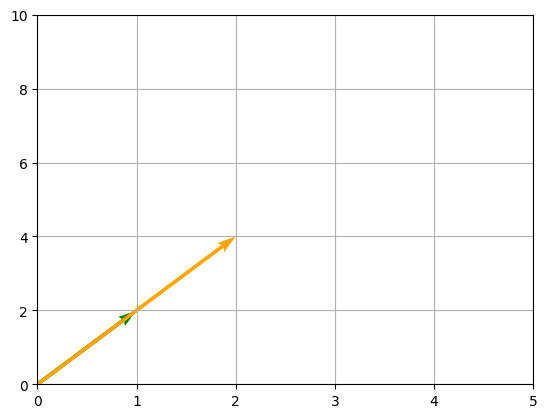

In [35]:
import matplotlib.pyplot as plt

v1 = np.array([1,2])
v2 = np.array([2,4])

plt.quiver(0,0,v1[0],v1[1],angles='xy',scale_units='xy', scale=1, color='green', label='v1')
plt.quiver(0,0,v2[0],v2[1],angles='xy',scale_units='xy', scale=1, color='orange', label='v2')

plt.grid()
plt.xlim(0,5)
plt.ylim(0,10)
plt.savefig(r"C:\Users\marco\Downloads\vectores_paralelos.png")
plt.show()


Ambos vectores están en la misma dirección.

---



# 15. Caso independiente

Vectores

$$
(1,0), (0,1)
$$



In [ ]:
A = np.array([
[1,0],
[0,1]
])

np.linalg.matrix_rank(A)


np.int64(2)

Rango = 2.

Generan todo el plano.

---



# 16. Aplicación directa en Machine Learning

En regresión lineal:

$$
y = X\beta
$$

Si las columnas de $X$ son dependientes:

no hay solución única.

Esto se llama

**multicolinealidad**.

---



# 17. Ejemplo práctico



In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['agua_suelo', 'lluvia', "humedad"]]
y = df['agua_suelo']

model = LinearRegression()

model.fit(X,y)

model.coef_  # agua_suelo = 0.8*lluvia + 0.6*humedad


array([0.5, 0.4, 0.3])

Los coeficientes se vuelven inestables.

---



# 18. Cómo detecta esto la ciencia de datos

Herramientas comunes:

* rango de la matriz
* SVD: Descomposición en Valores Singulares. 
* PCA: Análisis de Componentes Principales. 
* VIF: . 

---



# 19. Actividad de laboratorio

Eliminar la variable redundante.



In [ ]:
X = df[["lluvia","humedad"]]
y = df['agua_suelo']
model.fit(X,y)

model.coef_  # agua_suelo = 0.8*lluvia + 0.6*humedad

array([0.8, 0.6])

Comparar estabilidad del modelo.

---



# 20. Ejercicio conceptual

Determinar si los vectores son independientes.

$$
(1,2,3)
$$

$$
(2,4,6)
$$

$$
(1,0,1)
$$

Sugerencia:

usar rango de matriz asociada.

---



# 21. Ejercicio computacional

Simular variables dependientes.



In [ ]:
x1 = np.random.normal(size=300)
x2 = np.random.normal(size=300)

x3 = 3*x1 - 2*x2


Determinar rango.

---



# 22. Idea clave del módulo

La independencia lineal permite:

* descubrir estructura en datos
* eliminar redundancia
* estabilizar modelos
* entender geometría del dataset.

En esencia:

$$
Machine\ Learning = Geometría\ en\ espacios\ de\ alta\ dimensión
$$

---



# Mini-proyecto del módulo

Dataset climático con variables:

* radiación
* temperatura
* evapo_transpiración.

Detectar si hay dependencia lineal y reducir variables.

---
